## 06. 학습 관련 기술들
- 이번 장에서는 가중치 매개변수의 최적값을 탐색하는 최적화 방법, 가중치 매개변수 초깃값, 하이퍼파라미터 설정 방법 등에 대해서 다룸
- 과대 적합(Overfitting)의 대응책인 가중치 감소와 드롭아웃등의 정규화 방법에 대해서도 배우고 구현
- 배치 정규화도 짧게 알아봄

<이전 내용 복습>
입력(넘파이 배열) x -> Affine 계층(np.dot(x, W1) + b1) -> 활성화 함수(sigmoid, ReLU...) -> Affine 계층(np.dot(z, W2) + b2) -> softmax 함수(최종 출력층) -> 손실함수 L 계산 -> 오차역전파로 기울기(grad) 계산 -> 경사하강법으로 가중치 업데이트(W -= lr*grad)

- 오차역전파 = 기울기를 효율적으로 계산하기 위한 방법
- 확률적 경사 하강법(SGD) = 오차역전파에서 구한 기울기로 가중치를 업데이트
---

### 6-1. 매개변수 갱신 
- 신경망 학습의 목적 = 손실 함수의 값을 가능한 낮추는 가중치 매개변수를 찾는 것 = 매개변수의 최적값을 찾는 문제 = 최적화 작업
    - 지금까지는 이 최적화를 위해 매개변수의 기울기(미분)을 이용했고, 이 방법을 확률적 경사 하강법(SGD)라고 부름

#### 6-1-2. 확률적 경사 하강법(SGD)

In [2]:
class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

#### 6-1-3. SGD의 단점
- 아래 그래프와 같은 함수가 있다면, SGD에 의한 최적화 갱신 경로는 **최솟값인(0,0)까지 지그재그로 움직이니 비효율적**
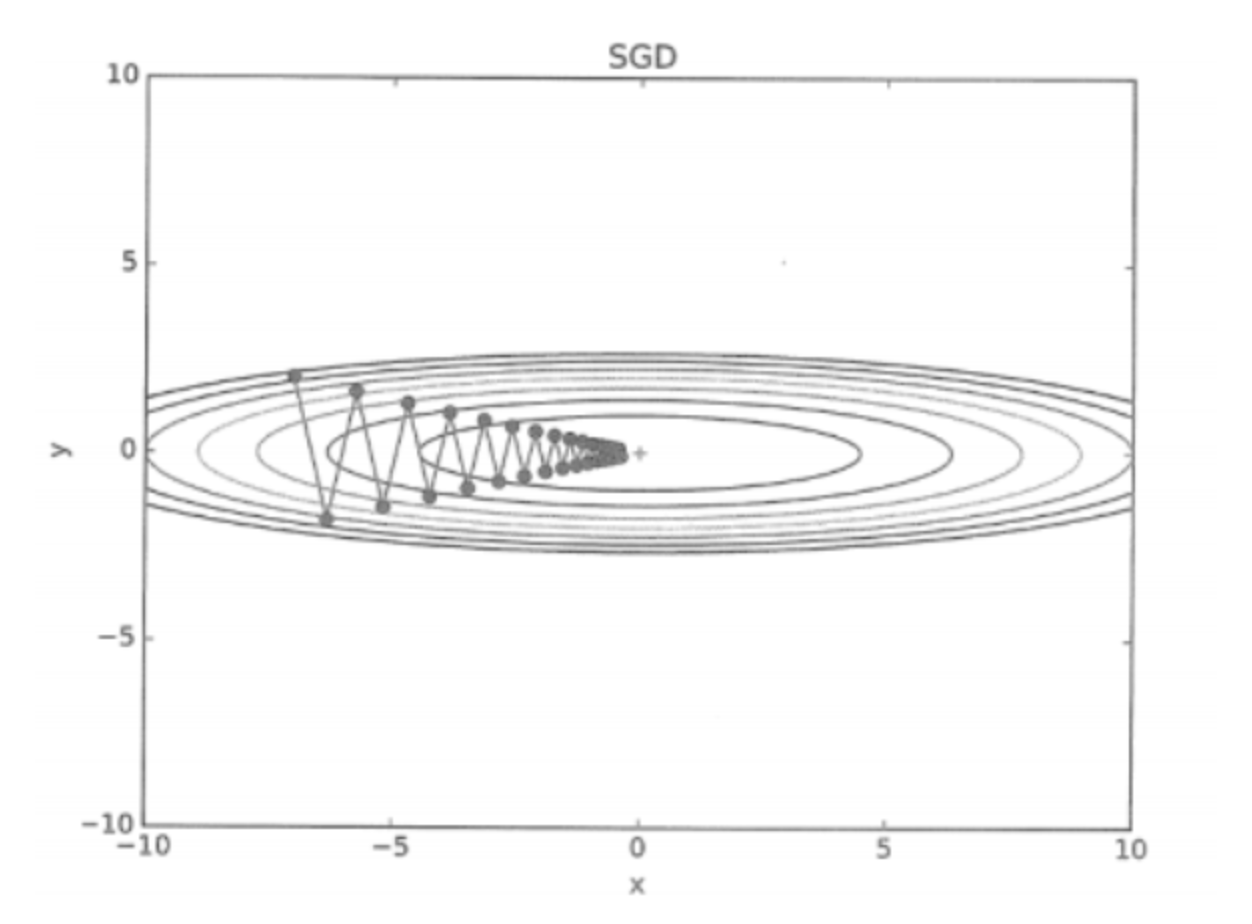

----
그래서,,,
이러한 SGD의 단점(비등방성에서는 탐색 경로가 비효율적임)을 개선해주는 **모멘텀, AdaGrad, Adam**이라는 세 방법이 나옴

#### 6-1-4. 모멘텀(Momentum)
- 운동량을 뜻하는 단어

In [4]:
import numpy as np

class Momentum:
    def __init__(self, lr = 0.01, momentum = 0.9):
        self.lr = lr
        self.momentum = momentum #중력같은 역할. 아무런 힘을 받지 않을 때 서서히 하강시키는 역할
        self.v = None

    #params = {
    #'W1': np.array([[0.1, 0.2], ...]),  
    #'b1': np.array([0.0, 0.0]),
    #'W2': np.array([[0.3, 0.4], ...]),
    #'b2': np.array([0.0, 0.0])
    #}
    def update(self, params, grads):
        if self.v is None:
            self.v = {} 
            for key, val in params.item(): #params = 가중치와 편향이 저장되어있는 딕셔너리 
                self.v[key] = np.zeros_like(val) #'W1' → W1과 같은 shape의 0 배열 / 'b1' → b1과 같은 shape의 0 배열...

        for key in params.keys():
            self.v[key] = self.momentum * self.v[key] - self.lr * grads[key] #grads = 가중치와 편향 기울기
            params[key] += self.v[key]

#### 6-1-5. AdaGrad
- 신경망 학습에는 학습률(learning rate)을 정하는게 가장 중요함
- 학습률을 정하는 효과적인 기술로는 **'학습률 감소'**가 있음
- ✅ **AdaGrad는 '각각의' 매개변수에 '맞춤형' 값을 만들어 줌**
- 아래 AdaGrad 구현 코드에서 주의해야할 점은 📍**마지막 줄에서 1e-7을 더하는 부분 = 0으로 나누는 사태를 막아줌**



In [5]:
class AdaGrad:
    def __init__(self, lr = 0.01):
        self.lr = lr
        self.h = None 

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

#### 6-1-6. Adam
- 모멘텀 = 공기 그릇 바닥을 구르는 듯한 움직임을 보임
- AdaGrad = 매개변수의 원소마다 적응적으로 갱신 정도를 조정
- Adam = 모멘텀 + AdaGrad를 결합한 방법 = 하이퍼파라미터의 '편향 보정'이 진행

In [6]:
class Adam:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None
        
    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)
        
        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)         
        
        for key in params.keys():
            #self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*grads[key]
            #self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*(grads[key]**2)
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])
            
            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

#### 6-1-7. 어느 갱신 방법을 이용할 것인가?
- 어떤 매개변수의 갱신 방법을 선택하느냐는 풀어야 할 문제가 무엇이냐에 따라 달라짐.
- 주로 SGD와 Adam을 많이 사용함

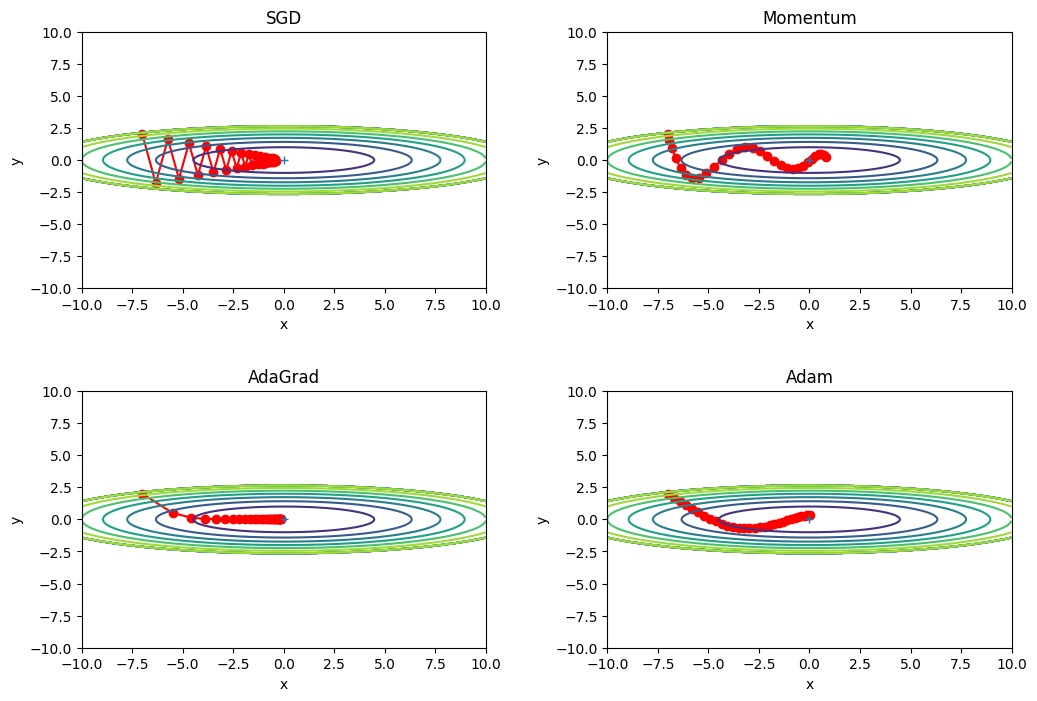

In [7]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

plt.figure(figsize=(12, 8))

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0
    
    # 그래프 그리기
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.subplots_adjust(wspace=0.3, hspace=0.4)    
plt.show()

#### 6-1-8. MNIST 데이터셋으로 본 갱신 방법 비교
- 손글씨 데이터셋(MNIST 데이터셋)으로 위에서 설명한 네가지 기법(Adam, 모멘텀, AdaGrad, SGD)를 비교해보자
- 각 층이 100개의 뉴런으로 구성된 5층 신경망에서 활성화 함수는 ReLU를 사용하여 측정

---
- 일반적으로는 SGD 보단 다른 세 기법이 빠르게 학습하고, 때로는 최종 정확도도 높게 나타남
- 📍**하지만, 하이퍼파라미터인 학습률과 신경망의 구조(레이어 수, 히든레이어 사이즈 등)에 따라 결과가 달라진다는 것을 항상 인지하고 있어야함.**

===========iteration:0===========
SGD:2.4183074457843396
Momentum:2.4032432443791207
AdaGrad:2.208875348247794
Adam:2.1856645759042372
===========iteration:100===========
SGD:1.530681048215156
Momentum:0.3845868667487949
AdaGrad:0.16970428910127328
Adam:0.25956375952293237
===========iteration:200===========
SGD:0.7807819842565614
Momentum:0.2430852821284179
AdaGrad:0.15439724058112386
Adam:0.17286704010475995
===========iteration:300===========
SGD:0.5367810667952582
Momentum:0.21800165832489232
AdaGrad:0.06732701624806614
Adam:0.14161057375987443
===========iteration:400===========
SGD:0.44550040199824903
Momentum:0.25508124342449323
AdaGrad:0.09013552067874026
Adam:0.1402369175265067
===========iteration:500===========
SGD:0.44171555161961285
Momentum:0.12438115297865257
AdaGrad:0.08388794205585895
Adam:0.09158511972122543
===========iteration:600===========
SGD:0.363536793629889
Momentum:0.12563691849321384
AdaGrad:0.06460453331852944
Adam:0.11688443792893444
===========iteration:7

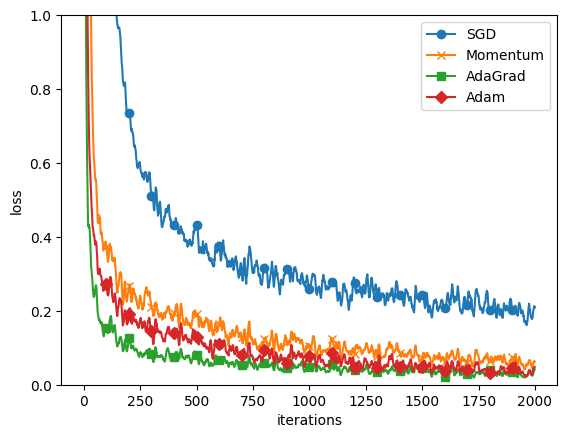

In [8]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
sys.path.append(os.path.join(current_dir, '..'))

import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

### 6-2. 가중치의 초깃값
- 신경망 학습에서는 가중치의 초깃값이 특히 중요함
- 권장 초깃값에 대해서 설명하고 실험을 통해 신경망 학습이 이뤄지는 모습을 확인

#### 6-2-1. 초깃값을 0으로 하면?
- 가중치의 초깃값 = 0.01 * np.random.randn(10,100)으로 설정
    - 초깃값을 이렇게 랜덤으로 설정하지 않고 모두 동일한 값으로 설정하면, 오차역전파법에서 갱신된 값들이 다 동일하기 때문에 학습이 이뤄지지 않음

#### 6-2-2. 은닉층의 활성화값 분포
- 가중치의 초깃값에 따라 은닉층 활성화값들이 어떻게 변화하는지 실험해볼 것.
- 활성화 함수로 시그모이드 함수를 사용하는 5층 신경망에 무작위로 생성한 입력 데이터를 흘리며 각 층의 활성화값 분포를 히스토그램으로 시각화